In [187]:
import pandas as pd
import importlib
import statsmodels.api as sm
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import edits_with_volume_plot as ewv
import tensorflow
import tensorflow_hub as hub
import numpy as np
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from ipywidgets import interact
_ = importlib.reload(ewv)

"""A shortcut for loading files from data directory"""
DR = "data/datasets/"

### Loading the SP500 Data

In [3]:
sp500 = yf.download("^GSPC", start="2009-01-01")
sp500 = sp500[["Close"]]
sp500["mkt_return"] = np.log(sp500["Close"] / sp500["Close"].shift(1))
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,mkt_return
Ticker,^GSPC,
Date,,
2009-01-02,931.799988,NaN
2009-01-05,927.450012,-0.004679
2009-01-06,934.700012,0.007787
2009-01-07,906.650024,-0.030469
2009-01-08,909.729980,0.003391


### Loading the tesla stock data

In [4]:
stock = ewv.prepare_stock_df(pd.read_csv(f"{DR}STOCK_tesla.csv"))
stock["log_return"] = np.log(stock['Close'] / stock['Close'].shift(1))

### Loading Elon Musk wiki data

In [188]:
msk = pd.read_csv(f"{DR}WIKI_elon_musk.csv")
msk = ewv.prepare_wiki_df(msk)

tsl = pd.read_csv(f"{DR}/WIKI_tesla.csv")
tsl = ewv.prepare_wiki_df(tsl)


agg = ewv.get_aggregated_wiki_stats(msk, "D")
agg_tsl = ewv.get_aggregated_wiki_stats(tsl, "D")

In [192]:
agg

,reverts_before,unique_editors_before,total_edits_before,reverts_after,unique_editors_after,total_edits_after
timestamp,,,,,,
2004-08-18,0,1,2,0.0,0.0,0.0
2004-08-19,0,0,0,0.0,0.0,0.0
2004-08-20,0,0,0,0.0,0.0,0.0
2004-08-21,0,0,0,0.0,0.0,0.0
2004-08-22,0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...
2026-03-20,0,0,0,0.0,1.0,1.0
2026-03-21,0,2,3,0.0,1.0,4.0
2026-03-22,0,0,0,0.0,1.0,1.0


In [190]:
agg.index = agg.index.tz_localize(None)
agg_tsl.index = agg_tsl.index.tz_localize(None)
stock.index = stock.index.tz_localize(None)
sp500.index = sp500.index.tz_localize(None)
agg.index = agg.index.normalize()

daily.index = daily.index.tz_localize(None)
daily.index = daily.index.normalize()
stock.index = stock.index.normalize()
sp500.index = sp500.index.normalize()
agg_tsl.index = agg_tsl.index.normalize()
# Rename columns with prefix
agg_tsl_renamed = agg_tsl.add_prefix("tsla_")

# Join to main dataframe
df_combined = agg.join(stock, how='inner')
df_combined = df_combined.join(agg_tsl_renamed, how='inner')
df_combined = df_combined.join(sp500["mkt_return"], how='inner')
df_combined = df_combined.join(daily, how='inner')

df_combined.dropna(inplace=True)
df_combined = df_combined.sort_index(axis=1)


In [176]:
def s(arr, k):
    return arr.shift(k)

In [193]:
df_combined["b4close_twts"] = df_combined["tweet_during"] + df_combined["tweet_after"].shift(1)
df_combined["b4close_msk_edits"] = df_combined["total_edits_before"] + df_combined["total_edits_after"].shift(1)

In [194]:
df_combined.columns

Index(['Close', 'Date', 'Volume', 'log_return', 'mkt_return', 'reverts_after',
       'reverts_before', 'total_edits_after', 'total_edits_before',
       'tsla_reverts_after', 'tsla_reverts_before', 'tsla_total_edits_after',
       'tsla_total_edits_before', 'tsla_unique_editors_after',
       'tsla_unique_editors_before', 'tweet_after', 'tweet_count',
       'tweet_during', 'unique_editors_after', 'unique_editors_before',
       'b4close_twts', 'b4close_msk_edits'],
      dtype='str')

In [ ]:
def interval_regression(a):
    # Use a copy so you don't destroy your original data!
    dff = df_combined[df_combined.Date.dt.year >= a].copy()

    # Use the filtered data (dff) in the regression
    lm = smf.ols("log_return ~ mkt_return + np.log1p(b4close_msk_edits) + b4close_twts", data=dff).fit(cov_type="HC1")
    print(f"--- Results for Year >= {a} ---")
    # print(lm.f_test("total_edits = total_edits_l1 = 0"))
    print(lm.summary())

interact(interval_regression, a=(2010, 2026, 1))

interactive(children=(IntSlider(value=2018, description='a', max=2026, min=2010), Output()), _dom_classes=('wi…

<function __main__.interval_regression(a)>

Daily wikipedia *views*: Tesla, Elon Musk -- $tsla\_views_t, msk\_views_t$ \
Daily wikipedia *edits*: Tesla, Elon Musk -- $tsla\_edits_t, msk\_edits_t$ \
Market return proxy: SP500 close daily, -- $mkt\_return_t$ \
Google search: Tesla, Elon Musk, -- $tsla\_gsearch_t, msk\_gsearch_t$ \
Elon musk daily tweets: -- $msk\_tweets_t$

---


Each daily variable should be aligned with market open and close times, meaning we count occurences from yesterday, 16:00 up to today 16:00 ET.


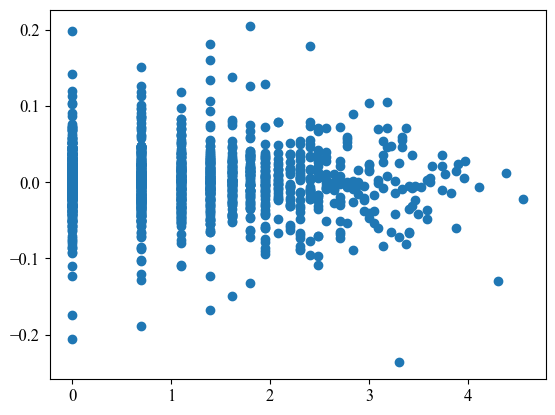

In [203]:
plt.scatter(np.log(df_combined["b4close_msk_edits"]), df_combined["log_return"])

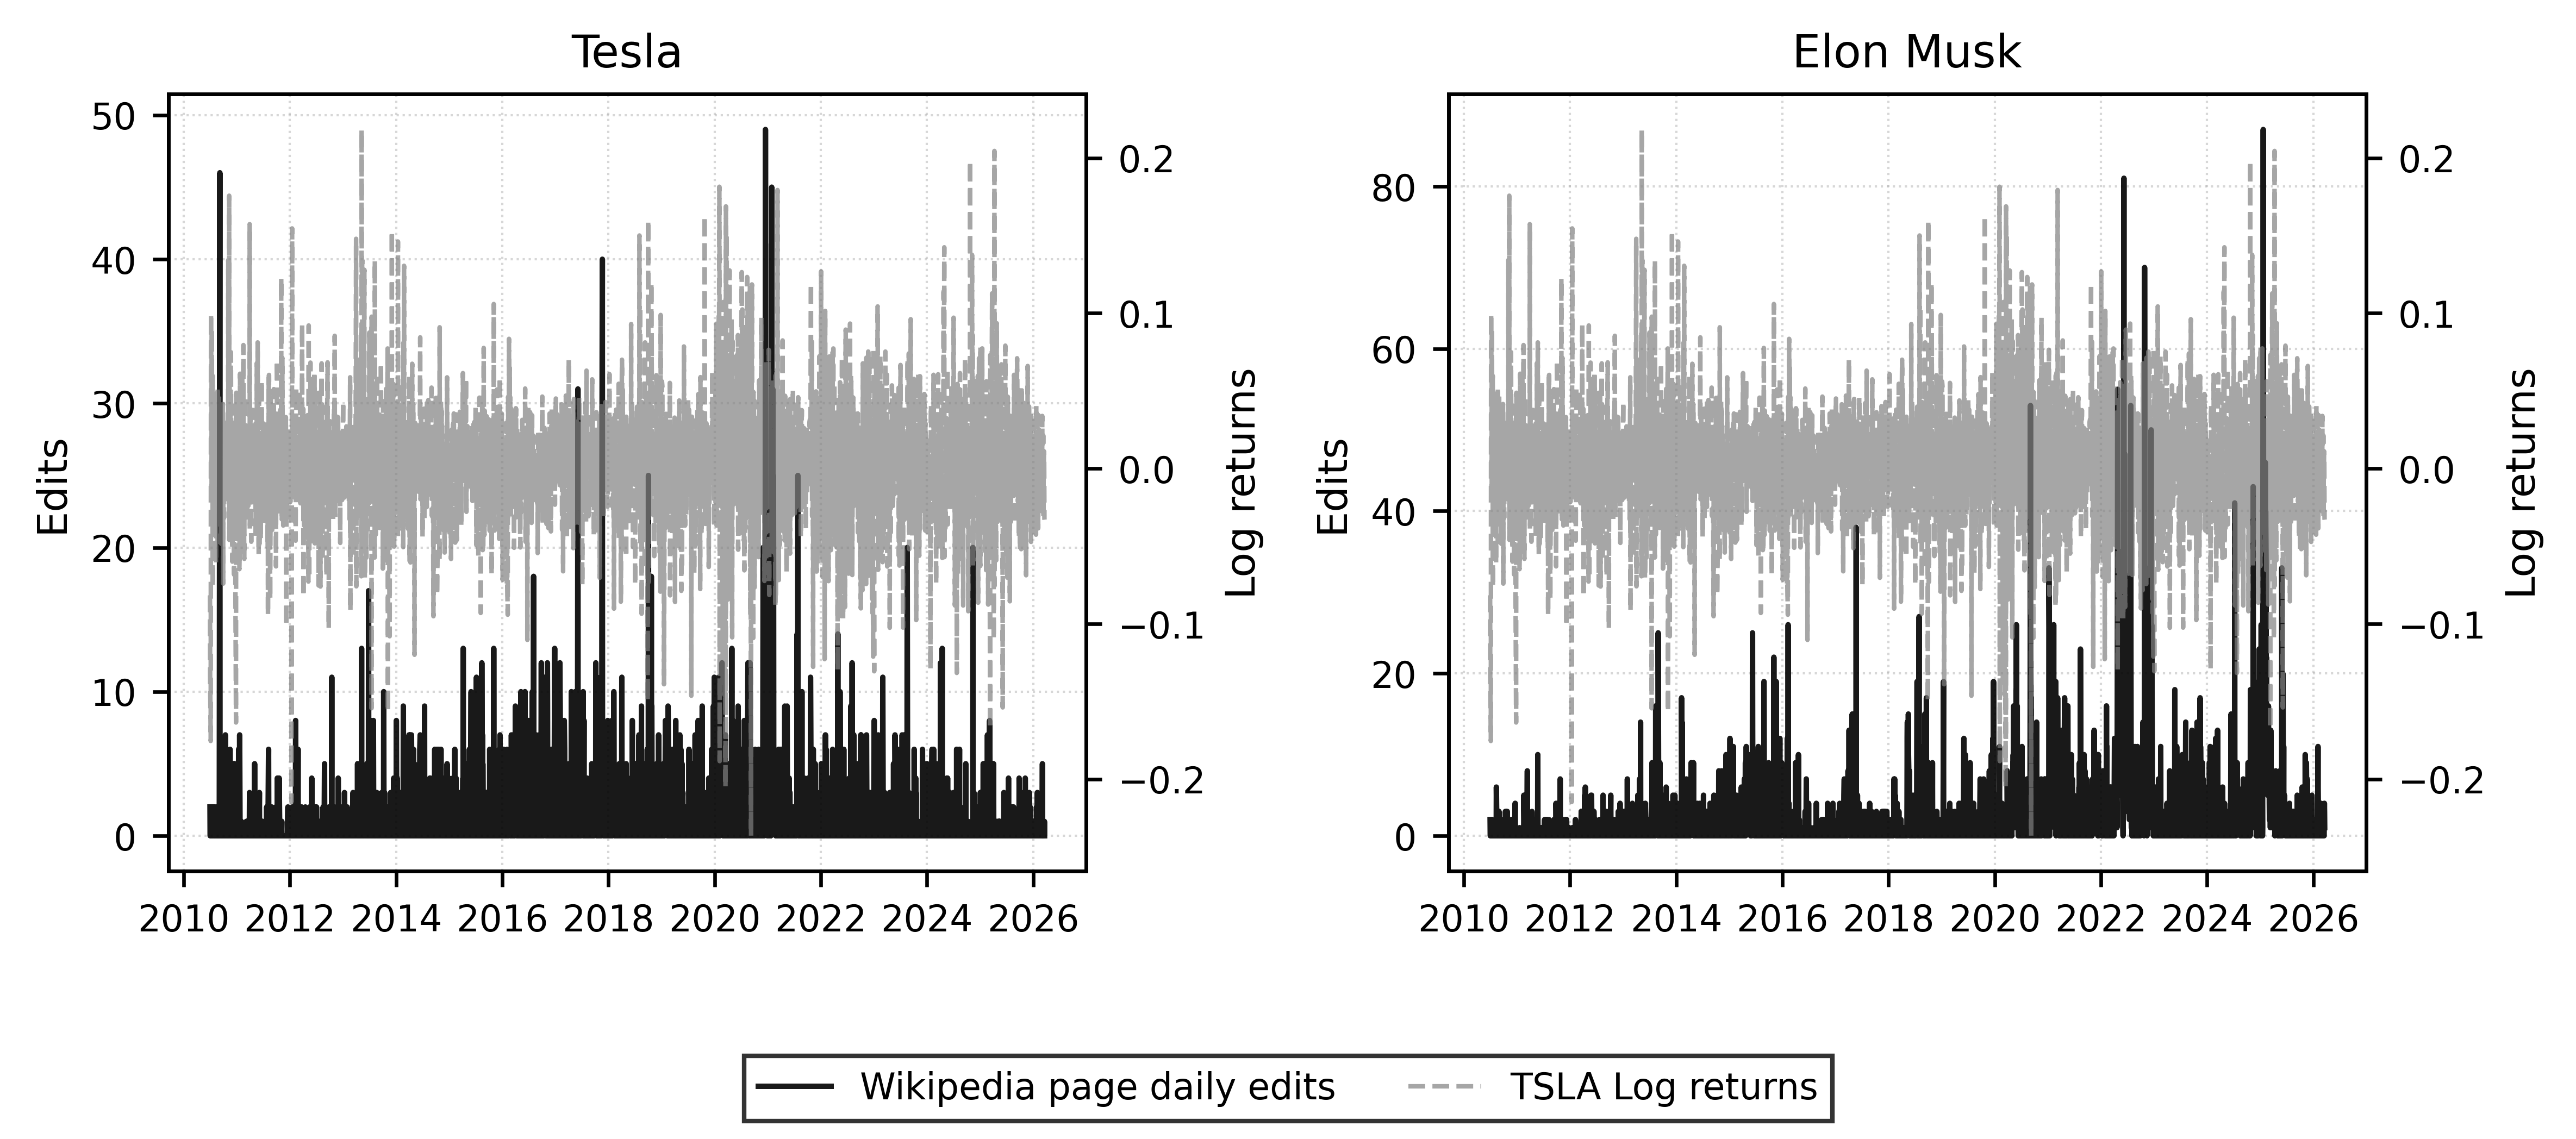

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=600, sharex=True)

# -------- Left subplot (Tesla page) --------
ax1 = axes[0]
l1, = ax1.plot(
    df_combined.tsla_total_edits,
    color='black',
    linewidth=1.2,
    alpha=0.9,
    label='Tesla page edits'
)

ax1b = ax1.twinx()
l2, = ax1b.plot(
    df_combined.log_return,
    color='gray',
    linewidth=1.0,
    linestyle='--',
    alpha=0.7,
    label='Log returns'
)

ax1.set_title('Tesla', fontsize=10)
ax1.set_ylabel('Edits', fontsize=9)
ax1b.set_ylabel('Log returns', fontsize=9)

# -------- Right subplot (Elon Musk page) --------
ax2 = axes[1]
l3, = ax2.plot(
    df_combined.total_edits,
    color='black',
    linewidth=1.2,
    alpha=0.9,
    label='Elon Musk page edits'
)

ax2b = ax2.twinx()
l4, = ax2b.plot(
    df_combined.log_return,
    color='gray',
    linewidth=1.0,
    linestyle='--',
    alpha=0.7
)

ax2.set_title('Elon Musk', fontsize=10)
ax2.set_ylabel('Edits', fontsize=9)
ax2b.set_ylabel('Log returns', fontsize=9)

# -------- Styling --------
for ax in [ax1, ax1b, ax2, ax2b]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(axis='both', labelsize=8)

for ax in axes:
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

# -------- Shared legend --------
fig.legend(
    [l1, l2],
    ['Wikipedia page daily edits', 'TSLA Log returns'],
    loc='lower center',
    ncol=3,
    fontsize=8,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

fig.tight_layout(rect=[0, 0.12, 1, 1])

plt.show()

In [ ]:
tweets["createdAt"] = pd.to_datetime(tweets.createdAt)
tweets = tweets.sort_values(by="createdAt")
tweets.set_index(tweets["createdAt"], inplace=True)
tweets["is_after_close"] = tweets.index.time >= pd.to_datetime("16:00").time()


In [172]:
tweets["date"] = tweets.index.date
daily = tweets.groupby("date").agg(
    tweet_count=("id", "count")
)
# during trading hours
during = tweets[~tweets["is_after_close"]].groupby("date").agg(
    tweet_during=("id", "count"),
)
after = tweets[tweets["is_after_close"]].groupby("date").agg(
    tweet_after=("id", "count")
)

daily = daily.join(during).join(after).fillna(0)